In [ ]:
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import pdb
import os

import clip  # 加载OpenAI的CLIP模型
# pip install git+https://github.com/openai/CLIP.git
# 注意不是 pip install clip，后者是一个不同的库!

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 加载CLIP预训练模型: ViT格式, 每个patch大小为16x16像素
# model, preprocess = clip.load("ViT-B/16", device=device)
# 如果从本地加载:
model, preprocess = clip.load(os.path.expanduser("4_7/ckpt/ViT-B-16.pt"), device=device)
model.eval()
print("加载CLIP完成！")

使用设备: cuda
加载CLIP完成！


In [2]:
"""
CLIP 模型配置对比表 

| 模型名称         | Embedding维度 | 视觉编码器类型 | 视觉编码器层数 | 文本编码器类型   | Patch大小 | 输入分辨率 |
| ViT-T/16         | 192          | ViT-T         | 12            | Transformer    | 16x16     | 224x224   |
| ViT-B/32         | 512          | ViT-B         | 12            | Transformer    | 32x32     | 224x224   |
| ViT-B/16         | 512          | ViT-B         | 12            | Transformer    | 16x16     | 224x224   |
| ViT-L/14         | 768          | ViT-L         | 24            | Transformer    | 14x14     | 224x224   |
| ViT-L/14@336px   | 768          | ViT-L         | 24            | Transformer    | 14x14     | 336x336   |

CLIP还有将ResNet作为视觉编码器的版本，如CLIP-RN50，但ViT版本在性能上更优
"""

'\nCLIP 模型配置对比表 \n\n| 模型名称         | Embedding维度 | 视觉编码器类型 | 视觉编码器层数 | 文本编码器类型   | Patch大小 | 输入分辨率 |\n| ViT-T/16         | 192          | ViT-T         | 12            | Transformer    | 16x16     | 224x224   |\n| ViT-B/32         | 512          | ViT-B         | 12            | Transformer    | 32x32     | 224x224   |\n| ViT-B/16         | 512          | ViT-B         | 12            | Transformer    | 16x16     | 224x224   |\n| ViT-L/14         | 768          | ViT-L         | 24            | Transformer    | 14x14     | 224x224   |\n| ViT-L/14@336px   | 768          | ViT-L         | 24            | Transformer    | 14x14     | 336x336   |\n\nCLIP还有将ResNet作为视觉编码器的版本，如CLIP-RN50，但ViT版本在性能上更优\n'

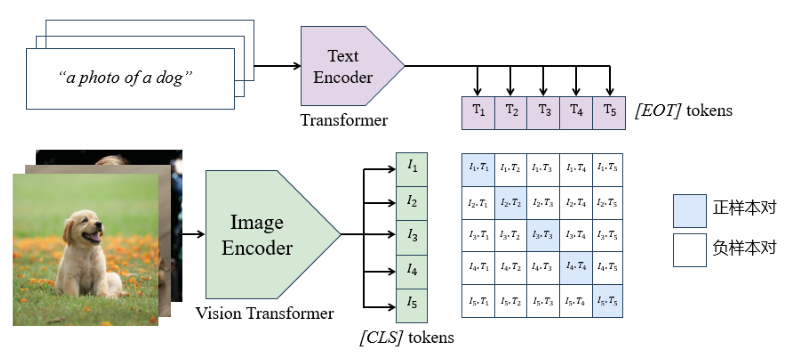

In [3]:
# 打印CLIP训练结构图
plt.figure(figsize=(10,5))
plt.imshow(Image.open('4_7/architecture/clip.png'))
plt.axis('off')
plt.show()

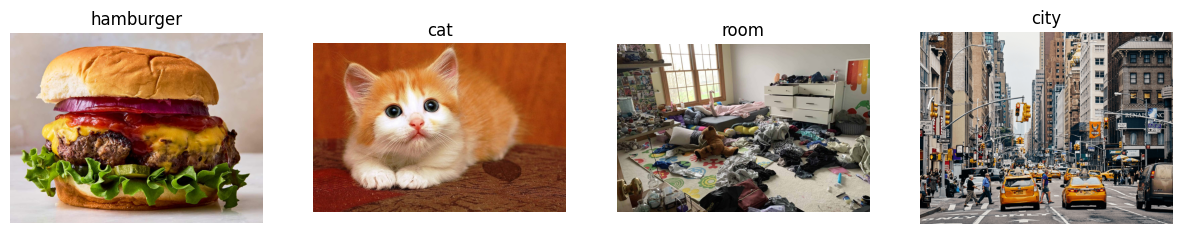

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# 注意, 以下图全部来自网络, 大概率没有在CLIP的训练数据中出现过，属于"零样本(zero-shot)"测试
images = {
    "hamburger": Image.open("4_7/clip/figs/hamburger.jpg").convert("RGB"), 
    "cat": Image.open("4_7/clip/figs/cat.jpg").convert("RGB"),       
    "room": Image.open("4_7/clip/figs/room.jpg").convert("RGB"),      
    "city": Image.open("4_7/clip/figs/city.jpg").convert("RGB")        
}

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, (name, img) in zip(axs, images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.show()

图像输入 torch.Size([1, 3, 224, 224])
文本库 torch.Size([4, 77])
文本库第一句话 tensor([49406,   320,  1125,   539,   320,  1530, 49407,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0], device='cuda:0',
       dtype=torch.int32)
图像特征: torch.Size([1, 512])
文本特征: torch.Size([4, 512])
图像-文本匹配度: torch.Size([1, 4])


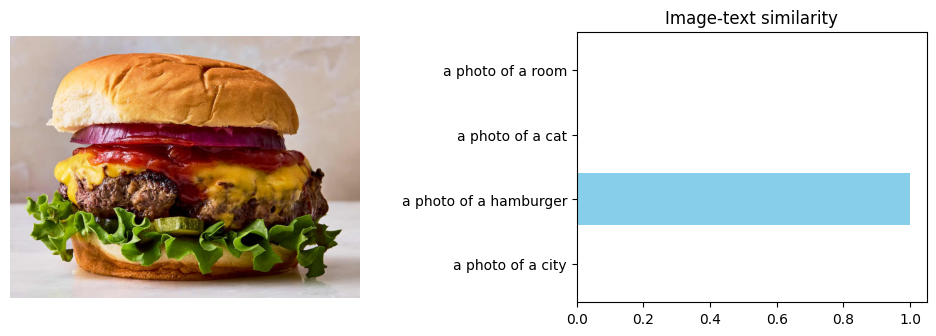

In [ ]:
# Task1: 给定图像, 匹配文本

target_img = images["hamburger"]

# 构造自然语义labels （你可以任意修改）
labels = ["a photo of a room", "a photo of a cat", "a photo of a hamburger", "a photo of a city"]

# 1. 图像预处理
image_input = preprocess(target_img).unsqueeze(0).to(device)
print("图像输入", image_input.shape)

# 2. 文本预处理
text_inputs = clip.tokenize(labels).to(device)
print("文本库", text_inputs.shape)
print("文本库第一句话", text_inputs[0])

# 3. 前向推理
with torch.no_grad():
    # 图像编码器：输出[CLS] token
    image_features = model.encode_image(image_input)
    print("图像特征:", image_features.shape)

    # 文本编码器: 输出[EOT] token
    text_features = model.encode_text(text_inputs)
    print("文本特征:", text_features.shape)

    # 图像&文本特征归一化
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # 图像&文本余弦相似度
    logit_scale = 100 # (缩放系数)
    logits_per_image = logit_scale * (image_features @ text_features.T) # 核心步骤
    print("图像-文本匹配度:", logits_per_image.shape)

    # Softmax 转为概率
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(target_img)
plt.axis("off")
plt.subplot(1, 2, 2)
y_pos = np.arange(len(labels))
plt.barh(y_pos, probs, align='center', color='skyblue')
plt.yticks(y_pos, labels)
plt.gca().invert_yaxis()
plt.title("Image-text similarity")
plt.tight_layout(pad=3.0)
plt.show()

文本输入 'great food', torch.Size([1, 77])
图像库 torch.Size([4, 3, 224, 224])
图像特征: torch.Size([4, 512])
文本特征: torch.Size([1, 512])
文本-图像匹配度: torch.Size([1, 4])


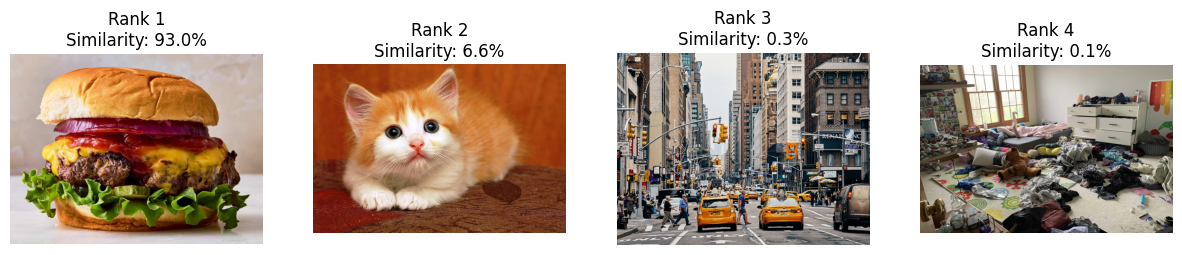

In [ ]:
# Task2: 给定文本, 匹配图像

# search_query = "busy street"
search_query = "great food"

gallery_images = list(images.values())
image_inputs = torch.cat([preprocess(img).unsqueeze(0) for img in gallery_images]).to(device)
text_input = clip.tokenize([search_query]).to(device)

print("文本输入", f"'{search_query}', {text_input.shape}")
print("图像库", image_inputs.shape)

with torch.no_grad():
    # 过程同上
    image_features = model.encode_image(image_inputs)
    print("图像特征:", image_features.shape)
    
    text_features = model.encode_text(text_input)
    print("文本特征:", text_features.shape)
    
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    
    logits_per_text = 100 * text_features @ image_features.T
    print("文本-图像匹配度:", logits_per_text.shape)
    
    similarity = logits_per_text.softmax(dim=-1).cpu().numpy()[0]

sorted_indices = np.argsort(similarity)[::-1]

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for i, idx in enumerate(sorted_indices):
    axs[i].imshow(gallery_images[idx])
    axs[i].set_title(f"Rank {i+1}\nSimilarity: {similarity[idx]:.1%}")
    axs[i].axis("off")
plt.show()

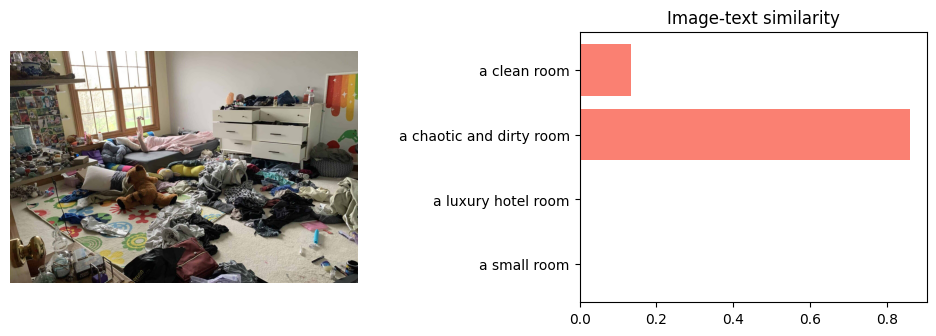

In [ ]:
# Task3: 给定图像, 匹配细粒度文本

target_img = images["room"]

labels = ["a clean room", "a chaotic and dirty room", "a luxury hotel room", "a small room"]

image_input = preprocess(target_img).unsqueeze(0).to(device)
text_inputs = clip.tokenize(labels).to(device)

with torch.no_grad():
    # 这里我们用 model(img, text)直接得到图像-文本相似度, 不再需要model.encode_image和model.encode_text
    logits_per_image, _ = model(image_input, text_inputs)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(target_img)
plt.axis("off")
plt.subplot(1, 2, 2)
y_pos = np.arange(len(labels))
plt.barh(y_pos, probs, align='center', color='salmon')
plt.yticks(y_pos, labels)
plt.gca().invert_yaxis()
plt.title("Image-text similarity")
plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
# 实验: 找春卷

# 在给定的图像库里,利用CLIP提供的图像-文本匹配功能,找出符合"春卷"的那张图

img_folder = os.path.expanduser("~/cv_course/4_7/clip/food101_demo")
img_names = sorted([f for f in os.listdir(img_folder) if f.endswith('.jpg')])
gallery_images = [Image.open(os.path.join(img_folder, name)).convert("RGB") for name in img_names]

text_query = "spring rolls"  # 当然你可以修改text_query本身
# 请模仿Task3的步骤, 实现以下功能:
# 1. 图像预处理 (hint: 遍历 gallery_images 并使用 preprocess)
# TODO:

# 2. 对 text_query 文本分词
# TODO:

with torch.no_grad():
    # 3. 调用model(image, text), 获取 logits, 计算出Softmax 概率, 返回probs
    # TODO: 

# 展示文-图相似度最高的那张图
top1_idx = np.argmax(probs)
plt.figure(figsize=(6, 5))
plt.imshow(gallery_images[top1_idx])
plt.title(f"Query: '{text_query}'\nSimilarity: {probs[top1_idx]:.1%}")
plt.axis("off")
plt.show()